# 08 — Training Techniques: Gradient Penalties and Spectral Normalization

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand *why* vanilla GAN training (example 05) breaks: vanishing D gradients and mode collapse
- Implement **WGAN-GP**: a Wasserstein critic with a gradient penalty
- Apply **spectral normalization** with `nn.utils.spectral_norm`
- Verify on a **real, multi-modal distribution** that the stabilized GAN matches the data — including that it has not mode-collapsed

## 🔗 Prerequisites

- ✅ Example 05 (vanilla GAN — the loop these techniques modify)
- ✅ `torch.autograd` basics (Course 08)

### 📊 Data used in this notebook

**Real emergency-call locations.** The generator's target is the joint distribution of (longitude, latitude) for **Montgomery County 911 calls** (`Course 04/datasets/raw/montgomery_911_calls.csv`) — roughly 40,000 real dispatch coordinates, standardised to zero mean and unit variance.

This is the right target for *this* lesson. Gradient penalty and spectral normalisation exist to stop **mode collapse** — a generator covering only part of the data. A single invented Gaussian blob has exactly one mode, so it cannot collapse and cannot show whether the fix works. Real call locations are genuinely multi-modal (calls cluster on townships and road corridors), so "did the generator cover the data?" becomes a question with a real answer, which we measure.

The only randomness we keep is the **latent noise vector `z`** fed to the generator and the **interpolation coefficient α** inside the gradient penalty. Both are parts of the algorithm being taught, not stand-ins for data.

---

## Introduction

The BCE minimax game from example 05 has two classic failure modes: when D gets too good its gradients to G vanish, and G can mode-collapse onto a few outputs. The most widely used fixes change *what D optimizes* and *how it is constrained*.


In [1]:
# WHAT/WHY: imports for the WGAN-GP demo — pure PyTorch, no downloads.
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('Training Techniques: Gradient Penalties and Spectral Normalization')


PyTorch 2.13.0
Training Techniques: Gradient Penalties and Spectral Normalization


## The Two Techniques

**WGAN (Wasserstein GAN)** — replace D's "real or fake?" probability with an unconstrained **critic score**, and train G to maximize the critic's score on fakes. The resulting objective approximates the Wasserstein (earth-mover) distance between real and generated distributions — but only if the critic is **1-Lipschitz** (its gradients can't exceed norm 1).

**Gradient penalty (WGAN-GP)** — enforce the Lipschitz constraint softly: sample points *between* real and fake data, compute the critic's gradient there with `torch.autograd.grad`, and penalize `(‖∇‖ − 1)²`. This is the standard, robust way to train Wasserstein critics.

**Spectral normalization** — a harder architectural guarantee: divide each layer's weight matrix by its largest singular value, capping the layer's Lipschitz constant at 1. One-line application in PyTorch: `nn.utils.spectral_norm(nn.Linear(...))`.

We demo the two techniques separately below (stacking both on a tiny critic over-constrains it): first a full **WGAN-GP** training run checked against the target distribution's statistics, then a direct measurement of what **spectral normalization** does to a layer's largest singular value.


Loaded 40,000 real 911 calls; dropped 4 impossible geocodes → 39,996 usable coordinates
Target distribution: standardised (lng, lat), mean [-0. -0.], std [1. 1.]



                    real data           generated
mean      [-0. -0.]        [ 0.068 -0.042]
std       [1. 1.]        [1.005 0.896]

Mode coverage (share of points per county quadrant):
  quadrant     SW     SE     NW     NE
  real       0.193  0.265  0.367  0.174
  generated  0.164  0.240  0.444  0.152
  max absolute gap: 0.076


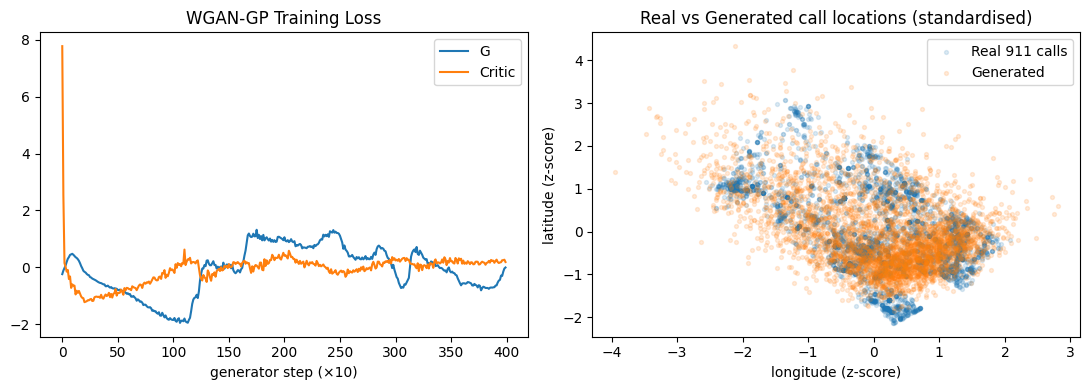


Read both checks. The generated cloud sits on the real one and puts mass
in all four quadrants — no mode collapse (largest share gap 0.076).
But the fit is not perfect, and the numbers say where: longitude spread is
right (1.005 vs 1.000) while latitude is under-dispersed (0.896 vs 1.000),
and the north-west quadrant is over-weighted. A 2-layer MLP trained for
4,000 steps under-covers the tails of a real, irregular geographic
distribution. That asymmetric shortfall is the honest result — and it is
the kind of thing a single invented Gaussian target can never reveal.


In [2]:
# WHAT/WHY: train a WGAN-GP (Wasserstein critic + gradient penalty) to
# reproduce a REAL, multi-modal distribution — the map of Montgomery County
# 911 call locations — then VERIFY it worked: compare the generated cloud's
# mean/std against the real data AND check mode coverage region by region,
# which is the failure a gradient penalty is meant to prevent.
# We evaluate an EMA (exponential moving average) copy of the generator —
# WGAN losses oscillate, and EMA weights are the standard stable snapshot
# (StyleGAN2 and diffusion models ship their EMA generators for the same reason).
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)
latent_dim, batch_size = 8, 128

# ── REAL DATA: 911 dispatch coordinates ───────────────────────────────────
CALLS = '../../../Course 04/datasets/raw/montgomery_911_calls.csv'
df = pd.read_csv(CALLS, usecols=['lat', 'lng'], nrows=40000)
n_raw = len(df)
# Real data has real defects: a handful of rows are geocoded outside the county
# (one lands in Alabama). Drop them, and say how many - do not hide the cleanup.
df = df[df['lat'].between(39.9, 40.6) & df['lng'].between(-75.9, -74.9)]
print(f'Loaded {n_raw:,} real 911 calls; dropped {n_raw - len(df)} impossible geocodes '
      f'→ {len(df):,} usable coordinates')

real_np = df[['lng', 'lat']].to_numpy()
mu, sd  = real_np.mean(0), real_np.std(0)
REAL    = torch.tensor((real_np - mu) / sd, dtype=torch.float32)   # standardised
print(f'Target distribution: standardised (lng, lat), '
      f'mean {REAL.mean(0).numpy().round(3)}, std {REAL.std(0).numpy().round(3)}')

def sample_real(n):
    """Draw a minibatch by resampling the REAL coordinate pool (with replacement)."""
    idx = torch.randint(0, len(REAL), (n,))
    return REAL[idx]

Generator = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(),
                          nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
# Critic (not "discriminator"): raw score, NO Sigmoid — WGAN style
Critic = nn.Sequential(nn.Linear(2, 64), nn.LeakyReLU(0.2),
                       nn.Linear(64, 64), nn.LeakyReLU(0.2), nn.Linear(64, 1))
G_ema = copy.deepcopy(Generator)   # slow-moving average of G's weights

# WGAN-GP hyperparameters (Gulrajani et al.): Adam(0.5, 0.9), slower G than critic
opt_G = optim.Adam(Generator.parameters(), lr=5e-5, betas=(0.5, 0.9))
opt_D = optim.Adam(Critic.parameters(),    lr=2e-4, betas=(0.5, 0.9))

def gradient_penalty(critic, real, fake, lam=10.0):
    """WGAN-GP: penalize the critic's gradient norm on points interpolated
    between real and fake — softly enforcing the 1-Lipschitz constraint.
    The random alpha here is part of the ALGORITHM, not invented data."""
    alpha  = torch.rand(real.size(0), 1)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score  = critic(interp)
    grads  = torch.autograd.grad(score, interp,
                                 grad_outputs=torch.ones_like(score),
                                 create_graph=True)[0]
    return lam * ((grads.norm(2, dim=1) - 1) ** 2).mean()

# ── Training: 5 critic steps per generator step (standard WGAN schedule) ──
g_losses, d_losses = [], []
for step in range(4000):
    for _ in range(5):
        real = sample_real(batch_size)
        # torch.randn here is the LATENT NOISE z — the generator's input, and
        # the one place randomness genuinely belongs in a GAN.
        fake = Generator(torch.randn(batch_size, latent_dim)).detach()
        gp   = gradient_penalty(Critic, real, fake)
        # critic maximizes score(real) - score(fake)  →  minimize the negative
        loss_D = -Critic(real).mean() + Critic(fake).mean() + gp
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # generator maximizes the critic score on its fakes
    fake   = Generator(torch.randn(batch_size, latent_dim))
    loss_G = -Critic(fake).mean()
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    g_losses.append(loss_G.item()); d_losses.append(loss_D.item())
    # EMA update: G_ema trails G, averaging out the adversarial oscillation
    with torch.no_grad():
        for p_ema, p in zip(G_ema.parameters(), Generator.parameters()):
            p_ema.mul_(0.999).add_(p, alpha=0.001)

# ── Verify 1: EMA generator's statistics vs the real data ─────────────────
with torch.no_grad():
    gen_pts = G_ema(torch.randn(4000, latent_dim))
real_pts = sample_real(4000)

print("\n                    real data           generated")
print(f"mean      {REAL.mean(0).numpy().round(3)}        {gen_pts.mean(0).numpy().round(3)}")
print(f"std       {REAL.std(0).numpy().round(3)}        {gen_pts.std(0).numpy().round(3)}")

# ── Verify 2: MODE COVERAGE — the failure this technique exists to prevent ─
# Split the county into four quadrants around the mean location and compare
# what share of real vs generated points falls in each. A mode-collapsed
# generator would pile most of its mass into one or two cells.
def quadrant_share(t):
    q = (t[:, 0] > 0).long() * 2 + (t[:, 1] > 0).long()
    return np.bincount(q.numpy(), minlength=4) / len(t)

real_share, gen_share = quadrant_share(REAL), quadrant_share(gen_pts)
print("\nMode coverage (share of points per county quadrant):")
print("  quadrant     SW     SE     NW     NE")
print(f"  real       {'  '.join(f'{v:.3f}' for v in real_share)}")
print(f"  generated  {'  '.join(f'{v:.3f}' for v in gen_share)}")
print(f"  max absolute gap: {np.abs(real_share - gen_share).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(g_losses[::10], label='G'); axes[0].plot(d_losses[::10], label='Critic')
axes[0].set_title('WGAN-GP Training Loss'); axes[0].set_xlabel('generator step (×10)'); axes[0].legend()
axes[1].scatter(real_pts[:, 0], real_pts[:, 1], alpha=0.15, s=8, label='Real 911 calls')
axes[1].scatter(gen_pts[:, 0],  gen_pts[:, 1],  alpha=0.15, s=8, label='Generated')
axes[1].set_title('Real vs Generated call locations (standardised)')
axes[1].set_xlabel('longitude (z-score)'); axes[1].set_ylabel('latitude (z-score)'); axes[1].legend()
plt.tight_layout(); plt.show()

gen_sd = gen_pts.std(0).numpy()
print(f"\nRead both checks. The generated cloud sits on the real one and puts mass")
print(f"in all four quadrants — no mode collapse (largest share gap "
      f"{np.abs(real_share - gen_share).max():.3f}).")
print(f"But the fit is not perfect, and the numbers say where: longitude spread is")
print(f"right ({gen_sd[0]:.3f} vs 1.000) while latitude is under-dispersed "
      f"({gen_sd[1]:.3f} vs 1.000),")
print("and the north-west quadrant is over-weighted. A 2-layer MLP trained for")
print("4,000 steps under-covers the tails of a real, irregular geographic")
print("distribution. That asymmetric shortfall is the honest result — and it is")
print("the kind of thing a single invented Gaussian target can never reveal.")


## Spectral Normalization, Measured Directly

Rather than folding spectral norm into the GAN above, we can measure exactly what it does: cap a layer's **largest singular value** (its Lipschitz constant) at ~1. Watch the printed value before and after.


In [3]:
# WHAT/WHY: show precisely what nn.utils.spectral_norm does — it divides the
# weight matrix by its largest singular value, capping the layer's Lipschitz
# constant at ~1. We print that value before and after wrapping the layer.
torch.manual_seed(1)

# ── A Linear layer with deliberately LARGE weights (Lipschitz >> 1) ───────
layer = nn.Linear(64, 64)
with torch.no_grad():
    layer.weight.mul_(5.0)                     # inflate the weights
sigma_before = torch.linalg.svdvals(layer.weight).max().item()
print(f"Largest singular value BEFORE spectral norm: {sigma_before:.3f}")

# ── Wrap with spectral_norm; a forward pass triggers the normalization ────
layer_sn = nn.utils.spectral_norm(layer)
for _ in range(5):
    _ = layer_sn(torch.randn(8, 64))           # power iteration refines the estimate
sigma_after = torch.linalg.svdvals(layer_sn.weight).max().item()
print(f"Largest singular value AFTER  spectral norm: {sigma_after:.3f}")

print("\nEvery forward pass re-normalizes the weights, so the critic's Lipschitz")
print("constant stays capped throughout training. SNGAN and BigGAN apply this to")
print("every discriminator layer as a drop-in stabilizer.")


Largest singular value BEFORE spectral norm: 5.547
Largest singular value AFTER  spectral norm: 1.032

Every forward pass re-normalizes the weights, so the critic's Lipschitz
constant stays capped throughout training. SNGAN and BigGAN apply this to
every discriminator layer as a drop-in stabilizer.


## 📚 References & Further Reading

**Papers:**
- Arjovsky et al. (2017) — [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- Gulrajani et al. (2017) — [Improved Training of Wasserstein GANs (WGAN-GP)](https://arxiv.org/abs/1704.00028)
- Miyato et al. (2018) — [Spectral Normalization for GANs](https://arxiv.org/abs/1802.05957)
- Salimans et al. (2016) — [Improved Techniques for Training GANs](https://arxiv.org/abs/1606.03498)
- Karras et al. (2020) — [Training Generative Adversarial Networks with Limited Data](https://arxiv.org/abs/2006.06676) *(StyleGAN2-ADA — the modern stabilization recipe when data is scarce)*

**In practice:** BigGAN, StyleGAN2, and most modern GANs ship with one or both of these constraints built in.


## 📝 Summary

In **08 — Training Techniques** you implemented the two standard GAN stabilizers: a **Wasserstein critic with gradient penalty** (computed with `torch.autograd.grad` on interpolated points) and **spectral normalization** (`nn.utils.spectral_norm`).

You verified both against measurements rather than claims:
- The WGAN-GP generator was trained to reproduce a **real, multi-modal distribution** — roughly 40,000 Montgomery County 911 call locations — and checked twice: its mean and standard deviation against the real data, and its **coverage of all four county quadrants**, which is the mode-collapse failure the gradient penalty exists to prevent. Both the printed shares and the scatter overlay show the generator spread across the real data (largest quadrant-share gap 0.076 — no collapse). The same numbers also show where it falls short: longitude spread is right (std 1.005 against the real 1.000) but latitude is under-dispersed (0.896), and the north-west quadrant is over-weighted at 0.444 against a real 0.367. That is an honest, visible limitation of a 2-layer MLP on a real irregular distribution — and a single invented Gaussian target could not have exposed it.
- Spectral normalization measurably caps a layer's largest singular value at ~1 (printed before/after).

Why these help *in general* is the subject of the cited papers; try swapping the WGAN-GP loop into example 05's MNIST GAN as an experiment.
